In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets.csv')

df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], format='%m/%d/%Y')
df = df.rename(columns={'Disaster Type': 'Incident type'})

df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

print(df['Declaration Date'].isna().sum(), "missing dates found.")
yearly_counts = df.groupby('year').size()

type_trends = df.groupby(['year', 'Incident type']).size().unstack(fill_value=0)



0 missing dates found.


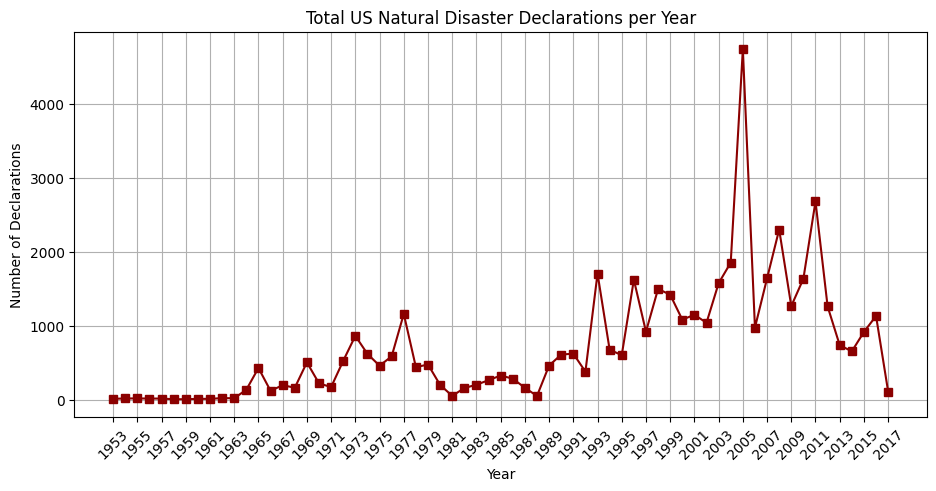

In [33]:
plt.figure(figsize=(11, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='s', color='darkred')
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 2), rotation=45)
plt.title('Total US Natural Disaster Declarations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Declarations')
plt.grid(True)
plt.show()

1. The line-chart displays the total number of disaster declarations in United States on annual basis from year 1953-2017
2. The pattern is a long-term increasing trend where we can see a massive spike of incident declarations in the year 2005.
3. The reason is likely due to frequent extreme weather and expanded federal reporting, while the 2005 spike is likely due to massive incident reportings.
Justifications:
4. Is there an increasing trend?
    Yes.We can see an increasing trend from 60's which disappeared around 80's but we can see another increasing trend starting from 90's compared to the 60's.
5. Any sudden spikes?
    Yes.Followed by the increasing trend we observed a massive spike in the year 2005.By referring the disaster type data in the year we see a unprecedented volume of Hurricane and Flood declarations that year.
6. Any abnormal drops?
    Yes.There is a sharp drop in 2006.It is likely becuase the incidents occured in 2005 haven't repeated in the succeeding year and led to the massive drop of incidetns recorded.

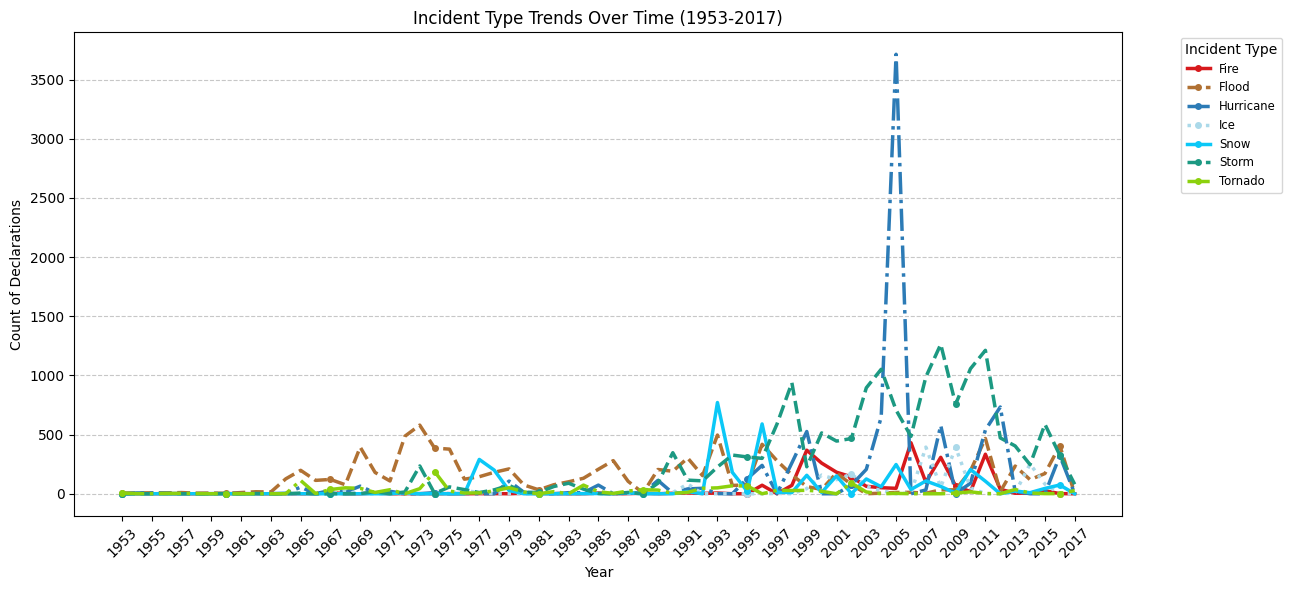

In [34]:
plt.figure(figsize=(13, 6))
type_counts = df['Incident type'].value_counts().head(7).index
type_trends = df[df['Incident type'].isin(type_counts)].groupby(['year', 'Incident type']).size().unstack(fill_value=0)

colors = ['#d7191c', "#b07133", '#2c7bb6', '#abd9e9', "#0bc8f7", "#1c9982", "#8cd10d"]
line_styles = ['-', '--', '-.', ':']

for i, column in enumerate(type_trends.columns):
    plt.plot(type_trends.index, 
             type_trends[column], 
             label=column, 
             color=colors[i], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5,
             marker='o', 
             markersize=4, 
             markevery=7)

plt.title('Incident Type Trends Over Time (1953-2017)')
plt.xlabel('Year')
plt.ylabel('Count of Declarations')

plt.xticks(range(int(type_trends.index.min()), int(type_trends.index.max()) + 1, 2), rotation=45)

plt.legend(title='Incident Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. This multiline chart compares annual frequency of top 7 most reported incidents from 1954-2017.
2. Hurricanes and Storms consistently show the highest count and where floods although not high, did show a consistent level of reportings.
3. These incidents are the most frequent because they affect large geographical regions simultaneously and occur across most seasons in the US.
Justifications:
4. Which disaster type is most frequent?
    floods were frequent till 90's and storms were the most frequent among all disasters occured.
5. Which type is increasing fastest?
    Hurricanes and storms are seen to be increasing the fastest with their frequncy doubling in the lates 80's and 90's with a sudden surge in later years.
6. Any type declining?
    Snow is seen declining just after its sudden rush in 90's and Tornadoes are seen to be the constantly the lowest recordings of among top 7.